In [1]:
import numpy as np
import pandas as pd
from stl import mesh
import matplotlib.pyplot as plt

from src.core.core import *
from src.core.transforms.translation import *
from src.core.transforms.rotation import *
from src.core.transforms.flexibility import *

In [2]:
stl_name = "rightWing"
stl_path =  "D:\Research\Kinematics_App\Data\Project_Files_2\Farhan_DrosophilaFine_1_5.STL"
stl_path_2 = "D:\Research\Kinematics_App\Data\Project_Files_2\Farhan_DrosophilaFine_1_5.STL"

stl = mesh.Mesh.from_file(stl_path)
stl_2 = mesh.Mesh.from_file(stl_path_2)

vectors_2 = stl_2.vectors
vectors_2 = np.array(vectors_2).reshape(-1, 3)
min_x_2 = np.min(vectors_2[:, 0])
max_x_2 = np.max(vectors_2[:, 0])
min_y_2 = np.min(vectors_2[:, 1])
max_y_2 = np.max(vectors_2[:, 1])
min_z_2 = np.min(vectors_2[:, 2])
max_z_2 = np.max(vectors_2[:, 2])

major_axis_2 = (max_x_2 - min_x_2)/2
minor_axis_2 = (max_y_2 - min_y_2)/2

print(major_axis_2, minor_axis_2)

vectors = stl.vectors
vectors = np.array(vectors).reshape(-1, 3)
min_x = np.min(vectors[:, 0])
max_x = np.max(vectors[:, 0])
min_y = np.min(vectors[:, 1])
max_y = np.max(vectors[:, 1])
min_z = np.min(vectors[:, 2])
max_z = np.max(vectors[:, 2])

major_axis = (max_x - min_x)/2
minor_axis = (max_y - min_y)/2

print(major_axis, minor_axis)

translation_transform = Translation_COM()
rotation_transform = ConstantR()

p = 0.8

positions = np.array(pd.read_csv(f"D:\Research\Kinematics_App\Data\Project_Files_2\\{p}\\accelerometer_values.csv"))
gamma_values = np.array(pd.read_csv(f"D:\Research\Kinematics_App\Data\Project_Files_2\\{p}\\alpha_values.csv"))
beta_values = np.array(pd.read_csv(f"D:\Research\Kinematics_App\Data\Project_Files_2\\{p}\\beta_values.csv"))
alpha_values = np.array(pd.read_csv(f"D:\Research\Kinematics_App\Data\Project_Files_2\\{p}\gamma_values.csv"))
m_values = np.array(pd.read_csv(f"D:\Research\Kinematics_App\Data\Project_Files_2\\{p}\\flexibility_values.csv"))

flexibility_transform = Flexibility_type2(x = False, y = False, z = True, y_min=min_y, major_axis = major_axis, minor_axis = minor_axis ,array_values = m_values, time_period = len(m_values), p=1-p)

object_temp = Object3D(stl_name, stl, translation_transform=translation_transform, rotation_transform=rotation_transform, flexibility_transform=flexibility_transform)

angles = np.hstack((alpha_values, beta_values, gamma_values))

sprite = Sprite(object_temp, positions, angles)

scene = Scene([sprite])

for i in range(75, 76):
    scene.save_stl(i, "D:\Research\Kinematics_App\Projectfiles\\output\\output" + str(i) + ".stl", reflect = False)

exception (False, 'b\'=-v5@v\\xf7\\xbaau\\xf7\\xca\\xbd/7(@\\xb4\\xf2\\xb5a(\\xd0\\xc3\\xb0\\xac\\x8d?@>\\xa4\\xbea(\\xd0\\xc3\\xb0\\x00\\x00\\xe1\\xb9q\\xbf\\xf1=\\xa8>\\x9c\\xd0\\xa9\\xbc-v5@v\\xf7\\xbaau\\xf7\\xca\\xbd\\xac\\x8d?@>\\xa4\\xbea(\\xd0\\xc3\\xb0i\\xad?@\\xd7\\xa2\\xbeau\\xf7\\xca\\xbd\\x00\\x00!\\xa5r\\xbfa\\xdd\\xa2>l\\xcb\\xa9\\xbci\\xad?@\\xd7\\xa2\\xbeau\\xf7\\xca\\xbd\\xac\\x8d?@>\\xa4\\xbea(\\xd0\\xc3\\xb0[\\xe7a@y\\x84\\xbfa(\\xd0\\xc3\\xb0\\x00\\x00\\xec\\xa3q\\xbf\\xe7/\\xa8>\\x11\\xd9\\t\\xbdi\\xad?@\\xd7\\xa2\\xbeau\\xf7\\xca\\xbd[\\xe7a@y\\x84\\xbfa(\\xd0\\xc3\\xb0>\\x00p@\\xcf\\x7f\\xc4au\\xf7\\xca\\xbd\\x00\\x00/\\xc8p\\xbf\\xcb\\x0c\\xad>\\\'%\\t=>\\x00p@\\xcf\\x7f\\xc4au\\xf7\\xca\\xbd[\\xe7a@y\\x84\\xbfa(\\xd0\\xc3\\xb0\\xfb4]@\\xb1\\x03\\xc9a(\\xd0\\xc3\\xb0\\x00\\x00`op\\xbfz\\xce\\xaf>\\x00\\x00\\x00\\x00>\\x00p@\\xcf\\x7f\\xc4au\\xf7\\xca\\xbd\\xfb4]@\\xb1\\x03\\xc9a(\\xd0\\xc3\\xb0\\xfb4]@\\xb1\\x03\\xc9au\\xf7\\xca\\xbd\\x00\\x00\\x99\\x18t\\xbf\\

In [3]:
temp_stl1 = copy.deepcopy(stl)
vectors = temp_stl1.vectors
vectors = np.array(vectors).reshape(-1, 3) + np.array([10, 20, 0])
temp_stl1.vectors = vectors.reshape(-1, 3, 3)
temp_stl1.save("D:\Research\Kinematics_App\Projectfiles\\output\\output_theta.stl")



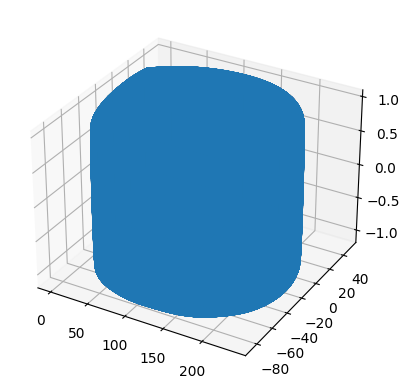

In [4]:
temp_stl = stl.vectors
temp_stl = np.array(temp_stl).reshape(-1, 3)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(temp_stl[:, 0], temp_stl[:, 1], temp_stl[:, 2])
plt.show()

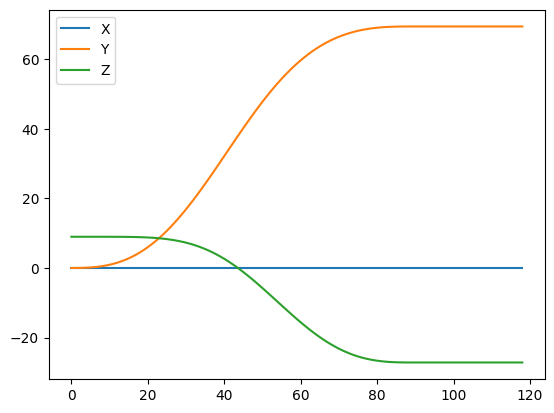

In [5]:
pos_x = positions[:, 0]
pos_y = positions[:, 1]
pos_z = positions[:, 2]

fig = plt.figure()
# Making plots
plt.plot(pos_x, label="X")
plt.plot(pos_y, label="Y")
plt.plot(pos_z, label="Z")
plt.legend()
plt.show()